In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manuel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/manuel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Science Process

> CRISP-DM CRoss Industry Standard Process for Data Mining

![alt](../assets/Screenshot%202026-06-25%20at%2012.20.14.png)

# Step 1: Business Understanding

# Data Understanding

In [2]:
df = pd.read_csv('../data/csv/tweet_emotion_dataset.csv')   # Read csv file
df = df.drop(columns=['tweet_id'])                          # Drop 'tweet_id' column
df.columns = ['emotion', 'content']                         # Rename columns
df.tail()

,emotion,content
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,Happy Mother's Day to all the mommies out ther...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...
39999,love,@mopedronin bullet train from tokyo the gf ...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


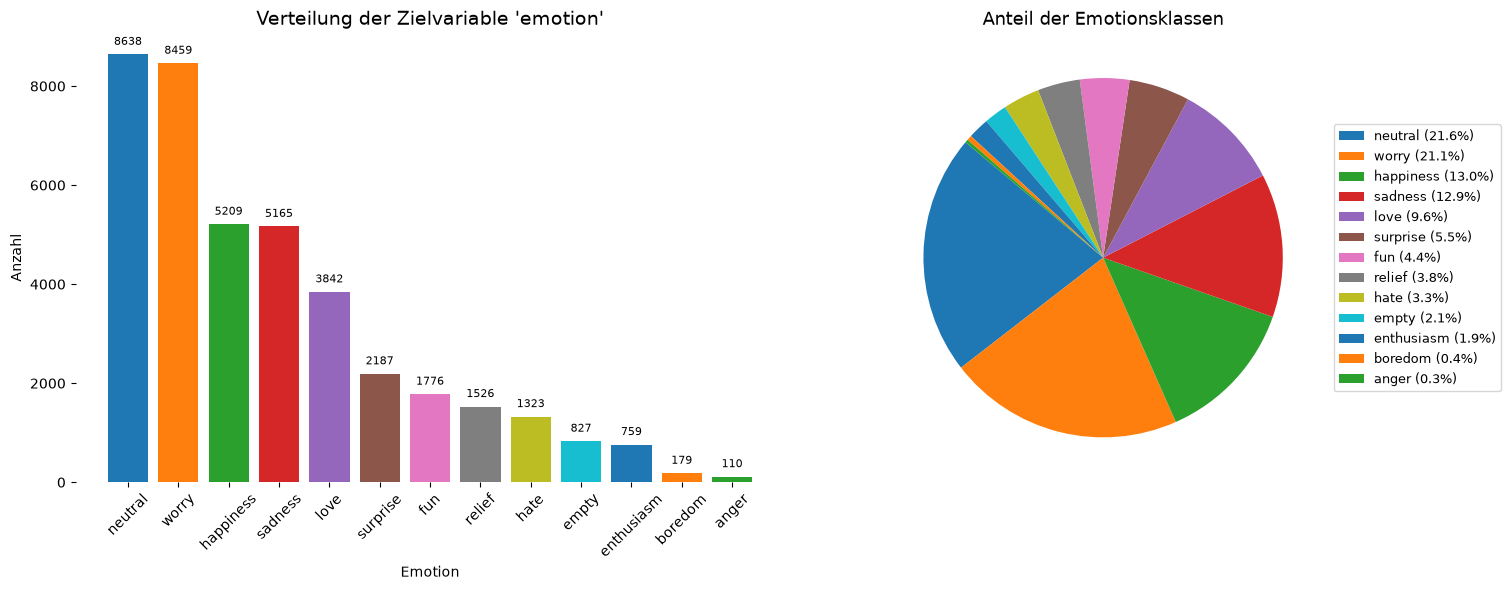

In [4]:
values = df["emotion"].value_counts()
labels = values.index
colors = plt.cm.tab10.colors

pct_labels = [f"{l} ({v/values.sum()*100:.1f}%)" for l, v in zip(labels, values)]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

bars = ax_bar.bar(labels, values, color=colors[:len(labels)])
ax_bar.set_title("Verteilung der Zielvariable 'emotion'", fontsize=14)
ax_bar.set_xlabel("Emotion")
ax_bar.set_ylabel("Anzahl")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.spines[:].set_visible(False)
_ = ax_bar.bar_label(bars, padding=5, fontsize=8)

wedges, _ = ax_pie.pie(values, colors=colors[:len(labels)], startangle=140)
ax_pie.set_title("Anteil der Emotionsklassen", fontsize=13)
ax_pie.legend(wedges, pct_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


# DATA CLEANING

| Schritt | Regex-Pattern | Beschreibung |
|---------|---------------|--------------|
| Kleinschreibung | `.lower()` | Vereinheitlichung Groß-/Kleinschreibung |
| URLs entfernen | `https?://\S+\|www\.\S+` | HTTP/HTTPS-Links und www-Adressen |
| Mentions entfernen | `@\w+` | Twitter-Nutzernamen wie `@user` |
| Hashtags entfernen | `#\w+` | Hashtags wie `#happy` |
| Sonderzeichen entfernen | `[^\w\s]` | Punkte, Kommas, Ausrufezeichen etc. |
| Zahlen entfernen | `\d+` | Reine Ziffernfolgen |
| Leerzeichen normalisieren | `\s+` → `' '` | Mehrfache Leerzeichen auf eines reduzieren |


Normalisierung, Skalierung und Standardisierung ist für unseren Datensatz nicht relevant, da es sich um textuelle Daten handelt, welche im folgenden sowieso durch Tokenisierung, Vektorisierung etc. weiterverarbeitet werden müssen. Eine verzeitige Normalisierung ist daher nicht notwendig. Normalisierung im Sinne von Lemmatisierung könnte angewendet werden.

- **Klassenungleichgewicht**: `neutral` (21,6 %) und `worry` (21,1 %) dominieren; `anger` hat nur 110 Einträge (0,3 %).
- *Die **Textlänge** variiert kaum zwischen den Emotionsklassen und ist daher kein Merkmal der Emotion.*
- Für das spätere Modell muss dieses Ungleichgewicht berücksichtigt

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


In [6]:
tokens = df.content.str.lower()                                         # Make text small case
tokens = tokens.str.replace(r'https?://\S+|www\.\S+', '', regex=True)   # Remove hyperlinks
tokens = tokens.str.replace(r'@\w+', '', regex=True)                    # Remove user mentions
# tokens = tokens.str.replace(r'#\w+', '', regex=True)                    # Remove hashtags
tokens = tokens.str.replace(r'[^\w\s]', '', regex=True)                 # Remove special characters
tokens = tokens.str.replace(r'\d+', '', regex=True)                     # Remove digits/numbers
tokens = tokens.str.replace(r'\s+', ' ', regex=True).str.strip()        # Remove double spaces
df["tokens"] = tokens

In [7]:
df = df[df.tokens != ""].dropna()
df = df.drop_duplicates(subset="tokens")

In [8]:
df["tokens"] = df["tokens"].str.split()

In [9]:
df.info()
df.tail()

<class 'pandas.DataFrame'>
Index: 38997 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  38997 non-null  str   
 1   content  38997 non-null  str   
 2   tokens   38997 non-null  object
dtypes: object(1), str(2)
memory usage: 4.2+ MB


,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,"[succesfully, following, tayla]"
39996,love,Happy Mothers Day All my love,"[happy, mothers, day, all, my, love]"
39997,love,Happy Mother's Day to all the mommies out ther...,"[happy, mothers, day, to, all, the, mommies, o..."
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,"[wassup, beautiful, follow, me, peep, out, my,..."
39999,love,@mopedronin bullet train from tokyo the gf ...,"[bullet, train, from, tokyo, the, gf, and, i, ..."


# WORD COUNTS

Anzahl Worte:  492001
|V|= 34338


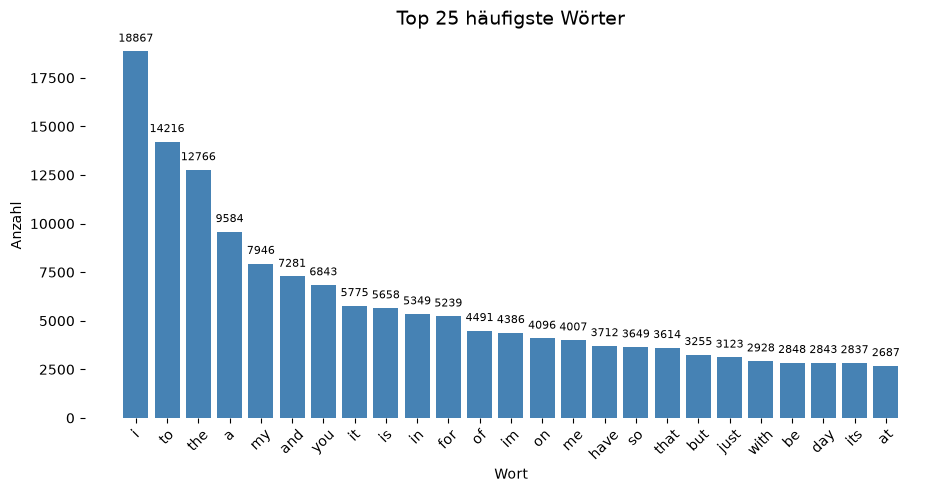

In [10]:
def plot_top_words(top_n=25):
    word_list = np.concatenate(df.tokens.values)

    word_counts = pd.Series(word_list).value_counts()
    word_counts = word_counts.reset_index()
    word_counts.columns = ["word", "count"]

    print("Anzahl Worte: ", len(word_list))
    print("|V|=", len(word_counts.word))

    top_words = word_counts.head(top_n)

    _, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(top_words["word"], top_words["count"], color="steelblue")
    ax.set_title(f"Top {top_n} häufigste Wörter", fontsize=14)
    ax.set_xlabel("Wort")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[:].set_visible(False)
    _ = ax.bar_label(bars, padding=5, fontsize=8)
    plt.show()

plot_top_words()

## Stopwords entfernen

In [11]:
stop_words = set(stopwords.words("english"))
stop_words.update(['u'])

print("Anzahl von Stopwords: " + str(len(stop_words)))
print("Stopwords: " + str(stop_words))

Anzahl von Stopwords: 199
Stopwords: {'ours', 'there', 'how', 'than', 'doesn', 'under', "won't", "wouldn't", "we'd", 'all', "he'd", 'u', "you'll", 'that', "isn't", 'had', 's', 'themselves', 'into', 'more', 'of', 'was', 'nor', 'himself', 'to', 'again', 're', 'will', "i'm", 'as', "i've", 'some', 'why', 'few', 'about', "she'd", 'shan', 'now', 'm', 'you', "it'll", 'haven', 't', "hasn't", 'should', "didn't", 'd', "he's", 'hadn', 'in', 'other', 'o', 'an', 'can', 'with', 'mustn', 'on', 've', 'through', 'is', 'they', 'during', "haven't", 'just', 'where', "he'll", 'then', 'who', 'whom', "hadn't", "we're", 'couldn', "it'd", 'doing', 'very', 'both', 'against', 'while', 'ain', "mightn't", 'here', 'won', 'if', 'hasn', 'll', 'its', "needn't", 'ourselves', "she'll", "doesn't", 'these', 'below', "don't", 'be', 'no', "that'll", 'are', 'so', 'her', "i'd", 'yours', 'myself', "they'll", 'because', 'having', 'does', 'further', 'yourselves', "weren't", 'before', "we've", 'after', "they're", 'theirs', 'from'

In [12]:
df.tokens = df.tokens.apply(lambda tokens: [w for w in tokens if w not in stop_words])

df.tail()

,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,"[succesfully, following, tayla]"
39996,love,Happy Mothers Day All my love,"[happy, mothers, day, love]"
39997,love,Happy Mother's Day to all the mommies out ther...,"[happy, mothers, day, mommies, woman, man, lon..."
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,"[wassup, beautiful, follow, peep, new, hit, si..."
39999,love,@mopedronin bullet train from tokyo the gf ...,"[bullet, train, tokyo, gf, visiting, japan, si..."


Anzahl Worte:  282217
|V|= 34195


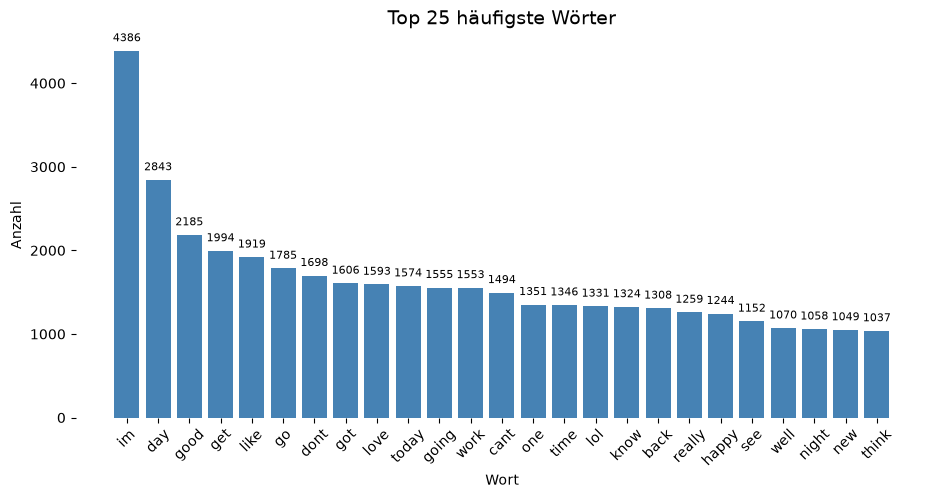

In [13]:
plot_top_words()

In [14]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
df["tokens"] = df.tokens.apply(lambda tokens: [stemmer.stem(w) for w in tokens])

df.tail()

,emotion,content,tokens
39994,happiness,Succesfully following Tayla!!,"[succes, follow, tayla]"
39996,love,Happy Mothers Day All my love,"[happi, mother, day, love]"
39997,love,Happy Mother's Day to all the mommies out ther...,"[happi, mother, day, mommi, woman, man, long, ..."
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,"[wassup, beauti, follow, peep, new, hit, singl..."
39999,love,@mopedronin bullet train from tokyo the gf ...,"[bullet, train, tokyo, gf, visit, japan, sinc,..."


In [15]:
def top_words_all(n=30):
    return pd.DataFrame([{
        "emotion": emotion,
        "top_words": pd.Series(
            np.concatenate(df[df["emotion"] == emotion]["tokens"].values)
        ).value_counts().head(n).index.tolist()
    } for emotion in df["emotion"].unique()]).set_index("emotion")

top_words_all()

,top_words
emotion,
empty,"[im, go, get, dont, bore, day, work, like, sle..."
sadness,"[im, go, miss, day, work, get, sad, like, toda..."
enthusiasm,"[go, im, get, want, work, good, day, like, tod..."
neutral,"[go, im, get, work, day, like, good, one, dont..."
worry,"[im, go, get, dont, day, work, feel, like, can..."
surprise,"[im, get, day, go, oh, like, got, see, know, c..."
love,"[love, day, happi, mother, im, good, thank, li..."
fun,"[im, lol, go, fun, get, day, good, like, haha,..."
hate,"[hate, im, get, work, go, like, suck, dont, ca..."


In [16]:
while common := set.intersection(*[set(w) for w in top_words_all().top_words]):
    df.tokens = df.tokens.apply(lambda t: [w for w in t if w not in common])
    print("Removed:", common)

Removed: {'get', 'day', 'go', 'like', 'im'}
Removed: {'one', 'work', 'time'}
Removed: {'know'}


Anzahl Worte:  259931
|V|= 27923


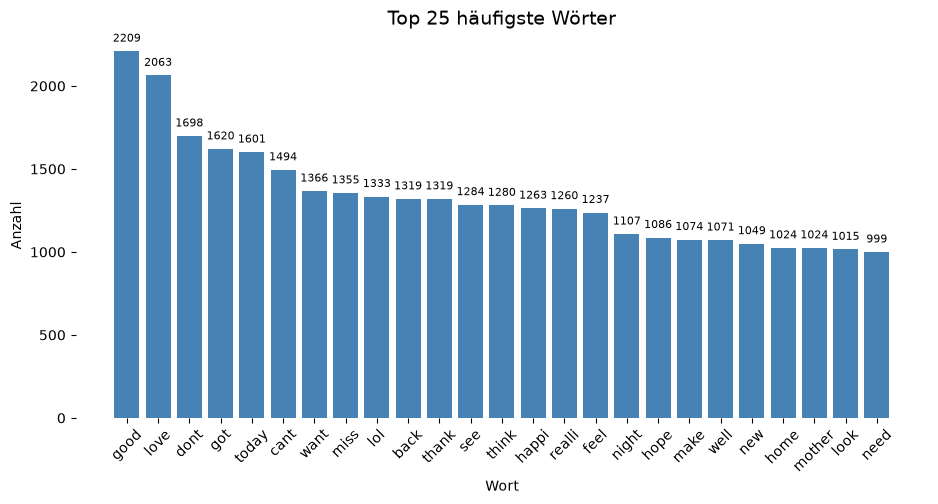

In [17]:
plot_top_words()

## Byte Pair Encoding

Byte Pair Encoding (BPE) ist für uns nicht weiter relevant, da es nicht auf Wort sondern auf Zeicheneben arbeitet. Dabei werden Wörter in Wortfragmente zerteilt, welches insbesondere für Transformer Modelle wichtig ist. Für einfache Classifier ist dies nicht notwendig oder ggf. sogar kontroproduktiv.

## Vektorisierung

In [18]:
keep = ["neutral", "worry", "happiness", "sadness", "love"]
# df_filtered = df[df.emotion.isin(keep)]
df_filtered = df


print(f"Verbleibende Klassen: {keep}")
print(f"Anteil am Gesamtdatensatz: {len(df_filtered) / 40000 * 100:.1f}%")
print(f"Verbleibende Einträge: {len(df_filtered)}")

Verbleibende Klassen: ['neutral', 'worry', 'happiness', 'sadness', 'love']
Anteil am Gesamtdatensatz: 97.5%
Verbleibende Einträge: 38997


In [19]:
X = df_filtered.tokens.apply(" ".join)
y = df_filtered.emotion

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### CountVectorizer (Bag-of-words)

In [20]:
count_vectorizer = CountVectorizer(ngram_range=(2,3))
X_count_train = count_vectorizer.fit_transform(X_train)
X_count_test  = count_vectorizer.transform(X_test)

print(count_vectorizer.get_feature_names_out().shape[0])

246904


### TFIDFVectorizer

In [21]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(2,3))
X_tfidf_train = tfidf_vectorizer.fit_transform(X_train)
X_tfidf_test  = tfidf_vectorizer.transform(X_test)

print(tfidf_vectorizer.get_feature_names_out().shape[0])

246904


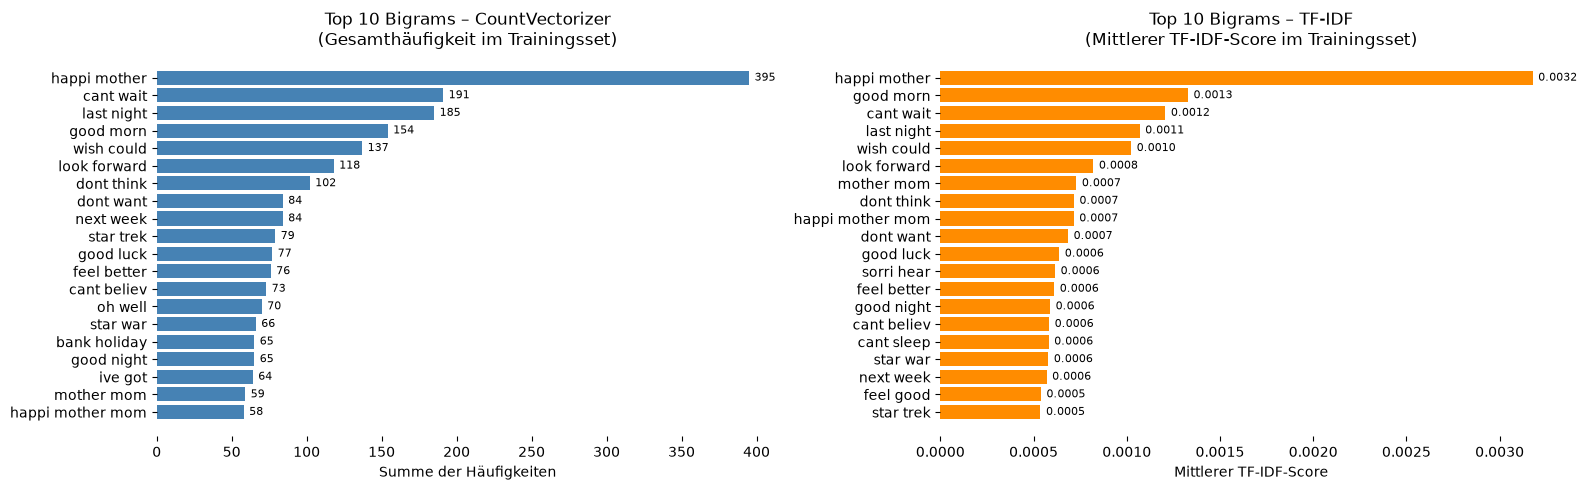

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Top 10 CountVectorizer features by total count
count_sums = np.asarray(X_count_train.sum(axis=0)).flatten()
count_top10_idx = count_sums.argsort()[::-1][:20]
count_features = count_vectorizer.get_feature_names_out()[count_top10_idx]
count_values = count_sums[count_top10_idx]

# Top 10 TF-IDF features by mean score
tfidf_means = np.asarray(X_tfidf_train.mean(axis=0)).flatten()
tfidf_top10_idx = tfidf_means.argsort()[::-1][:20]
tfidf_features = tfidf_vectorizer.get_feature_names_out()[tfidf_top10_idx]
tfidf_values = tfidf_means[tfidf_top10_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

bars1 = ax1.barh(count_features[::-1], count_values[::-1], color="steelblue")
ax1.set_title("Top 10 Bigrams – CountVectorizer\n(Gesamthäufigkeit im Trainingsset)", fontsize=12)
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.bar_label(bars1, fmt="{:.0f}", padding=4, fontsize=8)
ax1.spines[:].set_visible(False)

bars2 = ax2.barh(tfidf_features[::-1], tfidf_values[::-1], color="darkorange")
ax2.set_title("Top 10 Bigrams – TF-IDF\n(Mittlerer TF-IDF-Score im Trainingsset)", fontsize=12)
ax2.set_xlabel("Mittlerer TF-IDF-Score")
ax2.bar_label(bars2, fmt="{:.4f}", padding=4, fontsize=8)
ax2.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
classes = sorted(y_train.unique())
count_names = count_vectorizer.get_feature_names_out()
tfidf_names = tfidf_vectorizer.get_feature_names_out()
y_train_arr = y_train.values

fig, axes = plt.subplots(len(classes), 2, figsize=(16, len(classes) * 3))
fig.suptitle("Top 10 Features pro Klasse", fontsize=14, fontweight="bold", y=1.01)

for row, cls in enumerate(classes):
    mask = y_train_arr == cls

    cls_count = np.asarray(X_count_train[mask].sum(axis=0)).flatten()
    top_idx = cls_count.argsort()[::-1][:10]
    ax = axes[row, 0]
    bars = ax.barh(count_names[top_idx][::-1], cls_count[top_idx][::-1], color="steelblue")
    ax.set_title(f"{cls} – CountVectorizer", fontsize=10)
    ax.bar_label(bars, fmt="{:.0f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

    cls_tfidf = np.asarray(X_tfidf_train[mask].mean(axis=0)).flatten()
    top_idx = cls_tfidf.argsort()[::-1][:10]
    ax = axes[row, 1]
    bars = ax.barh(tfidf_names[top_idx][::-1], cls_tfidf[top_idx][::-1], color="darkorange")
    ax.set_title(f"{cls} – TF-IDF", fontsize=10)
    ax.bar_label(bars, fmt="{:.4f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
classes = sorted(y_train.unique())
tfidf_names = tfidf_vectorizer.get_feature_names_out()
y_train_arr = y_train.values

# Mean TF-IDF score per class for every term
class_scores = np.vstack([
    np.asarray(X_tfidf_train[y_train_arr == cls].mean(axis=0)).flatten()
    for cls in classes
])  # shape: (n_classes, n_features)

# Distinctiveness: score in this class minus max score in any other class
unique_words = {}
for i, cls in enumerate(classes):
    other_max = np.delete(class_scores, i, axis=0).max(axis=0)
    distinctiveness = class_scores[i] - other_max
    top_idx = distinctiveness.argsort()[::-1][:10]
    unique_words[cls] = tfidf_names[top_idx].tolist()

pd.DataFrame(unique_words)


## Modellierung

+ Inputvariablen:
+ Outputvariablen: 
+ Prediction vs. Inference: Prediction
+ Classification vs. Regression: Classification

In [ ]:
# CV + KNN

model_count_knn = KNeighborsClassifier(n_neighbors=21).fit(X_count_train, y_train)
print("=== CountVectorizer + KNN ===")
print(classification_report(y_test, model_count_knn.predict(X_count_test), zero_division=0))

In [ ]:
# CV + LR

model_count_lr = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_count_train, y_train)
print("=== CountVectorizer + LogisticRegression ===")
print(classification_report(y_test, model_count_lr.predict(X_count_test), zero_division=0))

In [ ]:
# CV + RF

model_count_rf = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_count_train, y_train)
print("=== CountVectorizer + RandomForest ===")
print(classification_report(y_test, model_count_rf.predict(X_count_test), zero_division=0))

In [ ]:
# TC + KNN

model_tfidf_knn = KNeighborsClassifier(n_neighbors=21).fit(X_tfidf_train, y_train)
print("=== TF-IDF + KNN ===")
print(classification_report(y_test, model_tfidf_knn.predict(X_tfidf_test), zero_division=0))

In [ ]:
# TC + LR

model_tfidf_lr = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_tfidf_train, y_train)
print("=== TF-IDF + LogisticRegression ===")
print(classification_report(y_test, model_tfidf_lr.predict(X_tfidf_test), zero_division=0))

In [ ]:
# TC + RF

model_tfidf_rf = RandomForestClassifier(class_weight="balanced", random_state=42).fit(X_tfidf_train, y_train)
print("=== TF-IDF + RandomForest ===")
print(classification_report(y_test, model_tfidf_rf.predict(X_tfidf_test), zero_division=0))